In [1]:
import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [2]:
zip_path = r"C:\Users\maxim\Downloads\mimic-iii-clinical-database-1.4.zip"

In [3]:
# ============================================================================
# LOAD CHARTEVENTS DATA FOR MEAN BLOOD PRESSURE
# ============================================================================
# MeanBP itemids
meanbp_itemids = [456, 52, 6702, 443, 220052, 220181, 225312]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('mimic-iii-clinical-database-1.4/CHARTEVENTS.csv.gz') as gz_file:
        chunk_iterator = pd.read_csv(gz_file, compression='gzip', chunksize=1_000_000)
        
        meanbp_chunks = []
        for i, chunk in enumerate(chunk_iterator):
            print(f"Processing CHARTEVENTS chunk {i+1}...")
            # Filter for MeanBP ITEMIDs only
            filtered = chunk[chunk['ITEMID'].isin(meanbp_itemids)]
            if not filtered.empty:
                meanbp_chunks.append(filtered)
        
        chartevents_meanbp = pd.concat(meanbp_chunks, ignore_index=True)

print(f"Loaded {len(chartevents_meanbp)} MeanBP measurements")

Processing CHARTEVENTS chunk 1...
Processing CHARTEVENTS chunk 2...
Processing CHARTEVENTS chunk 3...
Processing CHARTEVENTS chunk 4...
Processing CHARTEVENTS chunk 5...
Processing CHARTEVENTS chunk 6...
Processing CHARTEVENTS chunk 7...
Processing CHARTEVENTS chunk 8...
Processing CHARTEVENTS chunk 9...
Processing CHARTEVENTS chunk 10...
Processing CHARTEVENTS chunk 11...
Processing CHARTEVENTS chunk 12...
Processing CHARTEVENTS chunk 13...
Processing CHARTEVENTS chunk 14...
Processing CHARTEVENTS chunk 15...
Processing CHARTEVENTS chunk 16...
Processing CHARTEVENTS chunk 17...
Processing CHARTEVENTS chunk 18...
Processing CHARTEVENTS chunk 19...
Processing CHARTEVENTS chunk 20...
Processing CHARTEVENTS chunk 21...
Processing CHARTEVENTS chunk 22...
Processing CHARTEVENTS chunk 23...
Processing CHARTEVENTS chunk 24...
Processing CHARTEVENTS chunk 25...
Processing CHARTEVENTS chunk 26...
Processing CHARTEVENTS chunk 27...
Processing CHARTEVENTS chunk 28...
Processing CHARTEVENTS chunk 

Processing CHARTEVENTS chunk 232...
Processing CHARTEVENTS chunk 233...
Processing CHARTEVENTS chunk 234...
Processing CHARTEVENTS chunk 235...
Processing CHARTEVENTS chunk 236...
Processing CHARTEVENTS chunk 237...
Processing CHARTEVENTS chunk 238...
Processing CHARTEVENTS chunk 239...
Processing CHARTEVENTS chunk 240...
Processing CHARTEVENTS chunk 241...
Processing CHARTEVENTS chunk 242...
Processing CHARTEVENTS chunk 243...
Processing CHARTEVENTS chunk 244...
Processing CHARTEVENTS chunk 245...
Processing CHARTEVENTS chunk 246...
Processing CHARTEVENTS chunk 247...
Processing CHARTEVENTS chunk 248...
Processing CHARTEVENTS chunk 249...
Processing CHARTEVENTS chunk 250...
Processing CHARTEVENTS chunk 251...
Processing CHARTEVENTS chunk 252...
Processing CHARTEVENTS chunk 253...
Processing CHARTEVENTS chunk 254...
Processing CHARTEVENTS chunk 255...
Processing CHARTEVENTS chunk 256...
Processing CHARTEVENTS chunk 257...
Processing CHARTEVENTS chunk 258...
Processing CHARTEVENTS chunk

In [4]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # Load PATIENTS table
    with zip_ref.open('mimic-iii-clinical-database-1.4/PATIENTS.csv.gz') as gz_file:
        patients = pd.read_csv(gz_file, compression='gzip')
    
    # Load ICUSTAYS table
    with zip_ref.open('mimic-iii-clinical-database-1.4/ICUSTAYS.csv.gz') as gz_file:
        icustays = pd.read_csv(gz_file, compression='gzip')

In [5]:
# ============================================================================
# PROCESS MEAN BLOOD PRESSURE DATA
# ============================================================================
# Convert datetime columns
chartevents_meanbp['CHARTTIME'] = pd.to_datetime(chartevents_meanbp['CHARTTIME'])
icustays['INTIME'] = pd.to_datetime(icustays['INTIME'])

# Merge with ICUSTAYS to get admission times
meanbp_with_time = chartevents_meanbp.merge(
    icustays[['ICUSTAY_ID', 'HADM_ID', 'INTIME']], 
    on=['ICUSTAY_ID'], 
    how='inner'
)

# Calculate hours from ICU admission
meanbp_with_time['HOURS_FROM_ADMISSION'] = (
    meanbp_with_time['CHARTTIME'] - meanbp_with_time['INTIME']
).dt.total_seconds() / 3600

# Filter for first 48 hours (positive values, ≤ 48 hours)
meanbp_48h = meanbp_with_time[
    (meanbp_with_time['HOURS_FROM_ADMISSION'] > 0) & 
    (meanbp_with_time['HOURS_FROM_ADMISSION'] <= 48)
].copy()

# Clean MeanBP data
meanbp_clean = meanbp_48h[
    (meanbp_48h['VALUENUM'].notna()) & 
    (meanbp_48h['VALUENUM'] > 0) & 
    (meanbp_48h['VALUENUM'] < 300)&
    ((meanbp_48h['ERROR'].isna()) | (meanbp_48h['ERROR'] == 0))
].copy()

# ============================================================================
# CALCULATE MEAN BLOOD PRESSURE FEATURES
# ============================================================================
meanbp_features = meanbp_clean.groupby('ICUSTAY_ID').agg({
    'VALUENUM': ['mean', 'median', 'std', 'min', 'max', 'count']
}).reset_index()

meanbp_features.columns = ['ICUSTAY_ID', 'MEANBP_MEAN', 'MEANBP_MEDIAN', 
                            'MEANBP_STD', 'MEANBP_MIN', 'MEANBP_MAX', 'MEANBP_COUNT']

print(f"Extracted MeanBP features for {len(meanbp_features)} ICU stays")

Extracted MeanBP features for 52344 ICU stays


In [6]:
meanbp_features.head()

,ICUSTAY_ID,MEANBP_MEAN,MEANBP_MEDIAN,MEANBP_STD,MEANBP_MIN,MEANBP_MAX,MEANBP_COUNT
0,200001.0,71.145833,70.000000,7.184468,60.000000,91.000000,48
1,200003.0,75.987179,75.500000,14.907937,52.000000,179.000000,78
2,200006.0,72.666664,69.833351,8.873124,61.000000,97.333298,28
3,200007.0,77.190461,79.833298,13.253881,50.666698,109.333000,28
4,200009.0,75.322581,75.000000,9.827653,60.000000,101.000000,62


In [7]:
features = pd.read_csv('hr_rr_t_ag_dbp_sbp_age_gender_mortality_elixhauser_hem_urea_urine_rdw.csv')

features

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,HR_MEAN,HR_MEDIAN,HR_STD,HR_MIN,HR_MAX,HR_COUNT,RR_MEAN,...,UREA_COUNT,URINE_OUTPUT,RDW_mean,RDW_min,RDW_max,RDW_std,RDW_first,RDW_last,RDW_count,RDW_delta
0,268,110404,280836,103.101695,98.0,25.040447,73.0,190.0,59.0,26.862069,...,5.0,380.0,12.925000,12.7,13.1,0.206155,13.1,13.1,4.0,0.0
1,269,106296,206613,117.653846,116.0,15.438537,72.0,147.0,52.0,25.040816,...,5.0,8290.0,12.675000,12.5,12.8,0.150000,12.5,12.8,4.0,0.3
2,270,188028,220345,56.875000,60.0,6.499084,32.0,70.0,64.0,15.158730,...,3.0,4405.0,14.166667,14.0,14.4,0.208167,14.0,14.4,3.0,0.4
3,274,130546,254851,92.716981,93.0,11.774120,63.0,116.0,53.0,25.534884,...,3.0,3450.0,12.966667,12.6,13.7,0.635085,12.6,13.7,3.0,1.1
4,275,129886,219649,59.933333,59.0,8.632391,49.0,90.0,45.0,16.795455,...,2.0,2335.0,14.200000,14.1,14.3,0.141421,14.1,14.3,2.0,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21242,94933,163962,270429,111.625000,112.5,11.510633,85.0,134.0,48.0,21.404255,...,5.0,6750.0,16.116667,15.8,16.6,0.299444,16.1,16.6,6.0,0.5
21243,94944,143774,201233,87.218182,86.0,8.285844,66.0,106.0,55.0,19.333333,...,3.0,6185.0,12.725000,12.7,12.8,0.050000,12.8,12.7,4.0,-0.1
21244,94950,123750,283653,72.720000,70.0,13.516490,40.0,94.0,50.0,20.780000,...,3.0,1550.0,15.200000,15.2,15.2,0.000000,15.2,15.2,2.0,0.0
21245,94954,118475,202802,99.000000,97.0,14.645819,78.0,144.0,61.0,20.491803,...,3.0,3365.0,17.800000,17.2,18.3,0.556776,17.2,17.9,3.0,0.7


In [8]:
# Merge rdw features to feature df
final_df = features.merge(
    meanbp_features, 
    on='ICUSTAY_ID', 
    how='left'
)

In [9]:
final_df.to_csv('hr_rr_t_ag_dbp_sbp_age_gender_mortality_elixhauser_hem_urea_urine_rdw_abp.csv', index=False)

Correlation with MORTALITY_INHOSPITAL:
 MORTALITY_INHOSPITAL         1.000000
MORTALITY_90DAY              0.728106
MORTALITY_180DAY             0.647658
AG_MEAN                      0.239377
AG_MEDIAN                    0.235473
AG_MAX                       0.228449
age_adj_comorbidity_score    0.216348
comorbidity_score            0.207804
UREA_MIN                     0.205534
UREA_MEAN                    0.201946
AG_MIN                       0.201631
UREA_MEDIAN                  0.200646
UREA_MAX                     0.194075
RDW_max                      0.179599
RDW_last                     0.176521
RDW_mean                     0.175097
RDW_first                    0.169461
RDW_min                      0.167703
RR_MEAN                      0.142302
RR_MEDIAN                    0.135578
TEMP_STD                     0.124581
AGE                          0.116350
HR_MAX                       0.114212
HR_STD                       0.092724
HR_MEAN                      0.090737
HR_MEDIAN 

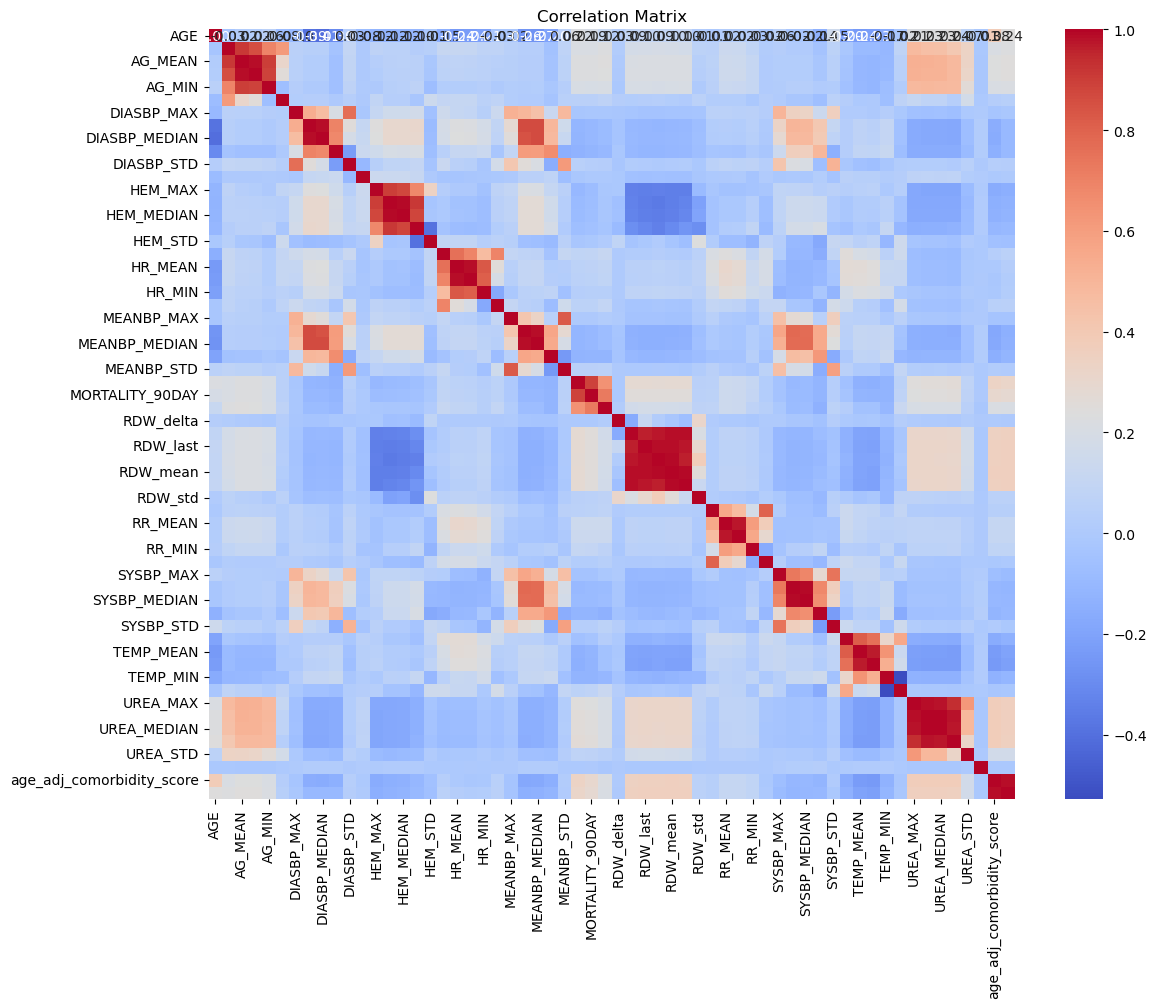

In [10]:
df_corr = final_df.copy()

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()

# Exclude columns
id_cols = ['SUBJECT_ID', 'ICUSTAY_ID', 'HADM_ID', 'HR_COUNT', 'SYSBP_COUNT', 'DIASBP_COUNT', 'TEMP_COUNT', 'AG_COUNT', 'RR_COUNT', 'HEM_COUNT', 'UREA_COUNT', 'RDW_count', 'HCT_count', 'MEANBP_COUNT']
numeric_cols = [col for col in numeric_cols if col not in id_cols]

# Sort alphabetically
numeric_cols = sorted(numeric_cols)

df_numeric = df_corr[numeric_cols]
corr_matrix = df_numeric.corr()

# Show correlation of features with target
target_corr = corr_matrix['MORTALITY_INHOSPITAL'].sort_values(ascending=False)
print("Correlation with MORTALITY_INHOSPITAL:\n", target_corr)

# Optional: Visualize correlation matrix
plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()